# Cosas pa hacer:
    - Imputar datos perdidos
    - Transformar datos (categorico -> numerico)
    - Aplicar KNN (hiper-parametros default)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import metrics
from sklearn import model_selection
from sklearn import preprocessing
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import GridSearchCV

from scipy.stats import chi2_contingency

from funcs import *

set_config(transform_output="pandas")
pd.set_option('future.no_silent_downcasting', True)

## Cargar los datos

In [2]:
url = 'https://raw.githubusercontent.com/AitzolSa/dataset/619ecb7ffa2bdfcfb5a589fb8266bcf0db15250d/archive.zip'

print("Descargando y leyendo el dataset desde GitHub...")
X = pd.read_csv(url, compression='zip')

print("¡Éxito! Aquí están los datos:")
X.head()

Descargando y leyendo el dataset desde GitHub...
¡Éxito! Aquí están los datos:


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


## Quitar variables complejas
    
    De momento quitaremos las de texto libre (luego podriamos añadirlas, por si son vacio, cortas, largas ...)

    - company_profile
    - description
    - requirements
    - benefits

In [3]:
variables_a_quitar = ["job_id","company_profile", "description", "requirements", "benefits"]

X = X.drop(variables_a_quitar, axis = 1)

## Dividir Train, Val y Test

In [4]:
# Dividimos train, test y validacion
semilla = 69

y = X.fraudulent
X_features = X.drop('fraudulent', axis=1)
X_resto, X_test, y_resto, y_test = model_selection.train_test_split(
    X_features, y, random_state=69, stratify=y, test_size=0.1
)
X_train, X_val, y_train, y_val = model_selection.train_test_split(
    X_resto, y_resto, random_state=69, stratify=y_resto, test_size=0.2
)

print("Train:")
print(X_train.describe())
print()

print("Val:")
print(X_val.describe())
print()

print("Test:")
print(X_test.describe())

Train:
       telecommuting  has_company_logo  has_questions
count   12873.000000      12873.000000   12873.000000
mean        0.042880          0.796784       0.492737
std         0.202595          0.402408       0.499967
min         0.000000          0.000000       0.000000
25%         0.000000          1.000000       0.000000
50%         0.000000          1.000000       0.000000
75%         0.000000          1.000000       1.000000
max         1.000000          1.000000       1.000000

Val:
       telecommuting  has_company_logo  has_questions
count    3219.000000       3219.000000    3219.000000
mean        0.042249          0.788444       0.483691
std         0.201188          0.408475       0.499812
min         0.000000          0.000000       0.000000
25%         0.000000          1.000000       0.000000
50%         0.000000          1.000000       0.000000
75%         0.000000          1.000000       1.000000
max         1.000000          1.000000       1.000000

Test:
       t

## Preprocesamiento de los Datos

In [5]:
# Esta clase sirve para convertir lo que devuelven los 
# transformers en dataframes de pandas
class DataFrameWrapper(BaseEstimator, TransformerMixin):
    def __init__(self, transformer):
        self.transformer = transformer

    def fit(self, X, y=None):
        self.transformer.fit(X, y)
        return self

    def transform(self, X):
        X_trans = self.transformer.transform(X)
        cols = self.transformer.get_feature_names_out()
        return pd.DataFrame(X_trans, columns=cols, index=X.index)

mg_agrup3 = ["employment_type","industry"]
mg_input3 = ["required_experience","function"]

mg_agrup4 = ["required_experience"]
mg_input4 = ["required_education"]

transformer1 = ColumnTransformer(transformers = [
    ("agruparInclusion",agrupar_por_inclusion(),["title","employment_type","required_experience","required_education","industry"]),
    ("rellenarSecuencial",rellenar_secuencial(),["salary_range"])],
                                remainder='passthrough',# Para que no destruya las colmnas que no toque
                                verbose_feature_names_out=False # Para que lo que devuelva sea legible (pone unas movidas que flipas)
                               )


transformer2 = ColumnTransformer(transformers = [
    ("rellenarModa",rellenar_con_moda(),["title","department","employment_type"]),
    ("rellenarConstante",rellenar_con_constante(),["industry"])],
                                remainder='passthrough',# Para que no destruya las colmnas que no toque
                                verbose_feature_names_out=False # Para que lo que devuelva sea legible (pone unas movidas que flipas)
                               )

transformer3 = ColumnTransformer(transformers = [
    ("rellenarModaGrupos",rellenar_moda_por_grupos(
        col_agrupacion = mg_agrup3, 
        cols_a_imputar = mg_input3),
     ["required_experience","employment_type","function","industry"])
    ],
                                remainder='passthrough',# Para que no destruya las colmnas que no toque
                                verbose_feature_names_out=False # Para que lo que devuelva sea legible (pone unas movidas que flipas)
                               )

transformer4 = ColumnTransformer(transformers = [
    ("rellenarModaGrupos",rellenar_moda_por_grupos(
        col_agrupacion = mg_agrup4, 
        cols_a_imputar = mg_input4),
     ["required_experience","required_education"])],
                                remainder='passthrough',# Para que no destruya las colmnas que no toque
                                verbose_feature_names_out=False # Para que lo que devuelva sea legible (pone unas movidas que flipas)
                               )
    
pipe = Pipeline([
    ("limpiaEspacios",limpiar_espacios()),
    ("minusculizar",minusculizar()),
    ("quitarSimbolos",quitar_simbolos()),
    ("quitarTildes",quitar_tildes()),
    ("transformer1", transformer1),
    ("transformer2", transformer2),
    ("transformer3", transformer3),
    ("transformer4", transformer4)
])

X_train_prep = pipe.fit_transform(X_train,y_train)
X_val_prep = pipe.transform(X_val)
X_resto_prep = pipe.transform(X_resto)

print("Preprocesamiento terminado correctamente")
X_val_prep.head()

Preprocesamiento terminado correctamente


,required_experience,required_education,employment_type,function,industry,title,department,salary_range,location,telecommuting,has_company_logo,has_questions
10995,midsenior level,bachelors degree,fulltime,administrative,unknown,marketing intern,sales,NaN,gb lnd,0,1,1
15826,midsenior level,unspecified,fulltime,information technology,information technology and services,presales engineer,technical,NaN,gb lnd london,0,1,0
1440,associate,unspecified,fulltime,other,financial services,recovery specialist,sales,NaN,us nv las vegas,0,1,0
8654,midsenior level,bachelors degree,fulltime,manufacturing,media production,production supervisor,sales,4000045000,us tx houston,0,1,1
14155,midsenior level,bachelors degree,fulltime,engineering,internet,partner services engineer,client services,4000045000,us ny new york,0,1,1


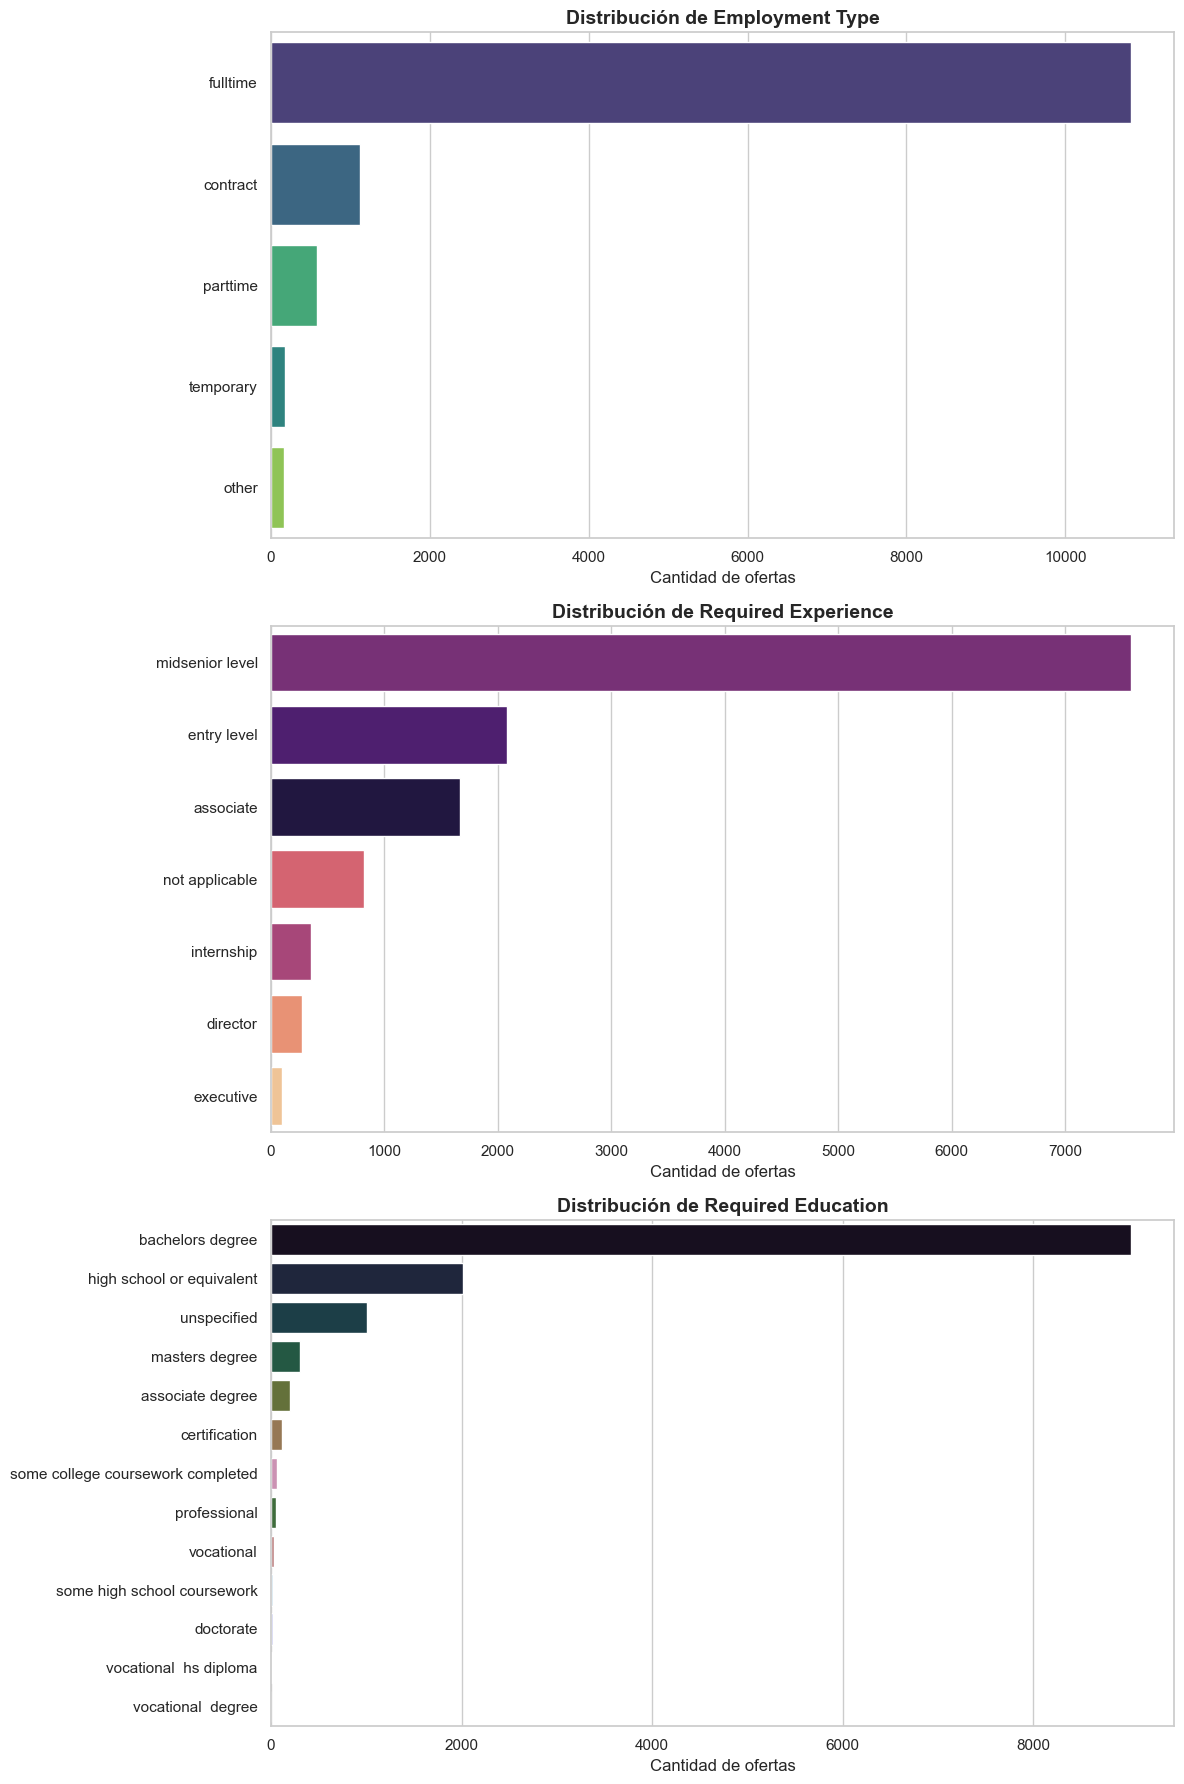

In [11]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(3, 1, figsize=(12, 18))

sns.countplot(y='employment_type', data=X_train_prep, ax=axes[0], 
              order=X_train_prep['employment_type'].value_counts().index, 
              palette='viridis', hue='employment_type', legend=False)
axes[0].set_title('Distribución de Employment Type', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cantidad de ofertas')
axes[0].set_ylabel('')

sns.countplot(y='required_experience', data=X_train_prep, ax=axes[1], 
              order=X_train_prep['required_experience'].value_counts().index, 
              palette='magma', hue='required_experience', legend=False)
axes[1].set_title('Distribución de Required Experience', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Cantidad de ofertas')
axes[1].set_ylabel('')

sns.countplot(y='required_education', data=X_train_prep, ax=axes[2], 
              order=X_train_prep['required_education'].value_counts().index, 
              palette='cubehelix', hue='required_education', legend=False)
axes[2].set_title('Distribución de Required Education', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Cantidad de ofertas')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

## Analisis de Relacion entre las Variables de Entrada y la de Salida

In [6]:
ranking = np.empty_like(X_train.columns, dtype = float)

for i, col in enumerate(X_train.columns):
    ranking[i] = v_cramer(X_train.loc[:,col],y_train)

orden = ranking.argsort()

print("Las variables ordenadas de menor a mayor pre preprocesamiento son: ")
for i in orden:
    print("{}: {}".format(X_train.columns[i],ranking[i]))

Las variables ordenadas de menor a mayor pre preprocesamiento son: 
telecommuting: 0.031779042275916804
employment_type: 0.0571215708036669
required_experience: 0.08209484577894716
has_questions: 0.08360873931607558
required_education: 0.16559307425867656
function: 0.17934590280301344
has_company_logo: 0.26978010695397747
salary_range: 0.30893855469036935
industry: 0.3209388535464321
department: 0.46500622247461165
location: 0.7012897178941595
title: 0.9532074521402328


In [7]:
ranking = np.empty_like(X_train_prep.columns, dtype = float)

for i, col in enumerate(X_train_prep.columns):
    ranking[i] = v_cramer(X_train_prep.loc[:,col],y_train)

orden = ranking.argsort()

print("Las variables ordenadas de menor a mayor post preprocesamiento son: ")
for i in orden:
    print("{}: {}".format(X_train_prep.columns[i],ranking[i]))

Las variables ordenadas de menor a mayor post preprocesamiento son: 
telecommuting: 0.031779042275916804
employment_type: 0.053228758372964466
has_questions: 0.08360873931607558
required_experience: 0.0842869427014179
function: 0.13878521648452768
required_education: 0.15370698890376763
has_company_logo: 0.26978010695397747
salary_range: 0.2704331304497382
industry: 0.3130044619420919
department: 0.4464638276366882
location: 0.6196973445191384
title: 0.7833885062953316


C:\Users\alumno\AppData\Local\Temp\ipykernel_14376\1631764107.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='has_company_logo', y='fraudulent', data=temp_df, palette='magma')


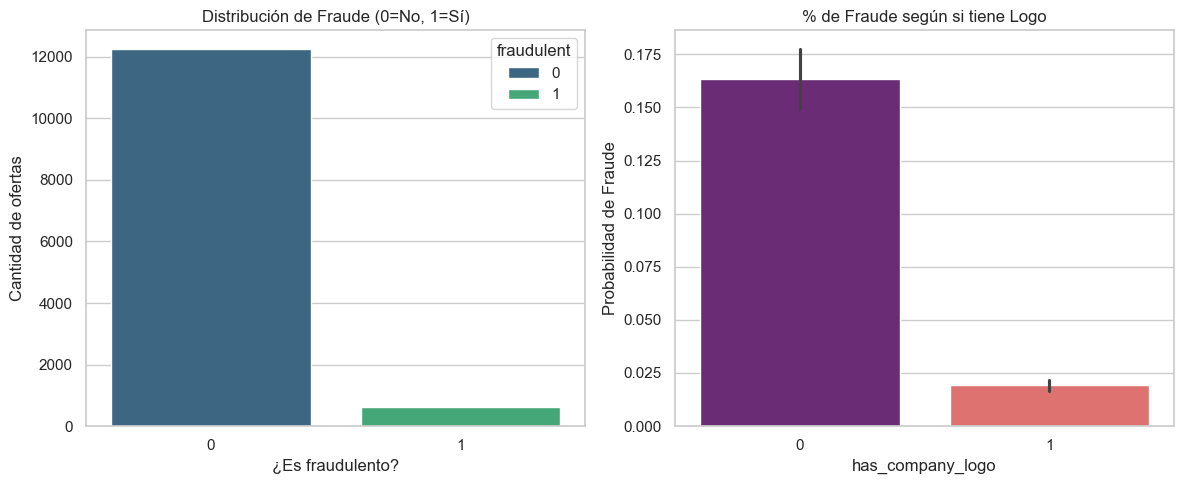

In [8]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

# Subplot 1: Desbalanceo de la clase
plt.subplot(1, 2, 1)
sns.countplot(x=y_train, hue=y_train, palette='viridis') 
plt.title('Distribución de Fraude (0=No, 1=Sí)')
plt.xlabel('¿Es fraudulento?')
plt.ylabel('Cantidad de ofertas')


plt.subplot(1, 2, 2)
temp_df = pd.concat([X_train_prep, y_train], axis=1)
sns.barplot(x='has_company_logo', y='fraudulent', data=temp_df, palette='magma')
plt.title('% de Fraude según si tiene Logo')
plt.ylabel('Probabilidad de Fraude')

plt.tight_layout()
plt.show()

## Metrica de Evaluacion 

    Depende un poco como para que vayamos a usar la información esto podría llegar a cambiar, pero de primeras vamos a fijar el criterio de evaluación para evitar los falsos negativos, si clasificamos algún fraude de más no importa demasiado porque querer. 
    
    Queremos detectar los ejemplos de la clase positiva lo mejor posible, por tanto usaremos el f1 score como métrica de rendimiento
    

In [9]:
cols_categoricas = ["title", "location", "department", "employment_type", 
                    "required_experience", "required_education", "industry", "function"]
cols_numericas = ["telecommuting", "has_company_logo", "has_questions"] 


preprocesador_final = ColumnTransformer(transformers=[
    ("target_enc", preprocessing.TargetEncoder(smooth="auto"), cols_categoricas),
    ("scaler", preprocessing.StandardScaler(), cols_numericas)
], remainder='drop')

modelo_completo = Pipeline([
    ("limpieza_custom", pipe),              
    ("codificacion_num", preprocesador_final), 
    ("knn", KNeighborsClassifier())        
])

params = {"knn__n_neighbors": [1,3,5,7], "knn__weights": ["uniform","distance"]}

print("Entrenando gridSearch...")
grid = GridSearchCV(modelo_completo,params, scoring = "f1")

grid.fit(X_resto_prep, y_resto)

print("Modelo entrenado")

Entrenando gridSearch...
Modelo entrenado


In [10]:
model = grid.best_estimator_
score = grid.best_score_
params = grid.best_params_

print("Mejor score obtenido en val: {}".format(score*100))
print("Parametros: {}".format(params))

preds = model.predict(X_test)
score_test = metrics.f1_score(preds, y_test)
print("Mejor score obtenido en test: {}".format(score_test*100))

Mejor score obtenido en val: 70.79987898433403
Parametros: {'knn__n_neighbors': 5, 'knn__weights': 'distance'}
Mejor score obtenido en test: 60.689655172413794
